In [31]:
import requests 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
all_books = []

In [34]:
for page in range(1, 35):  # 32 books per page, 35 pages ≈ 1120 books
    url = f"https://gutendex.com/books/?page={page}"
    response = requests.get(url)
    data = response.json()
    
    for book in data["results"]:
        all_books.append({
            "id": book["id"],
            "title": book["title"],
            "authors": ", ".join([a["name"] for a in book["authors"]]),
            "languages": ", ".join(book["languages"]),
            "download_count": book["download_count"],
            "media_type": book["media_type"],
            "subjects": ", ".join(book["subjects"][:3]),  # top 3 subjects
            "bookshelves": ", ".join(book.get("bookshelves", []))
        })

In [35]:
response

<Response [200]>

In [ ]:
all_books

In [ ]:
df = pd.DataFrame(all_books)

In [ ]:
df

In [ ]:
df.to_csv("books_dataset.csv", index=False)

In [2]:
df = pd.read_csv(r"F:\data analyst\EDA PROJECT\books_dataset.csv")
df

,id,title,authors,languages,download_count,media_type,subjects,bookshelves
0,2701,"Moby Dick; Or, The Whale","Melville, Herman",en,115502,Text,"Adventure stories, Ahab, Captain (Fictitious c...","Best Books Ever Listings, Category: Adventure,..."
1,2641,A Room with a View,"Forster, E. M. (Edward Morgan)",en,108984,Text,"British -- Italy -- Fiction, England -- Fictio...","Category: British Literature, Category: Novels..."
2,1080,A Modest Proposal: For preventing the children...,"Swift, Jonathan",en,96160,Text,Ireland -- Politics and government -- 18th cen...,"Category: British Literature, Category: Classi..."
3,84,"Frankenstein; Or, The Modern Prometheus","Shelley, Mary Wollstonecraft",en,95343,Text,Frankenstein's monster (Fictitious character) ...,"Category: British Literature, Category: Classi..."
4,3186,"The Mysterious Stranger, and Other Stories","Twain, Mark",en,86611,Text,"Humorous stories, American, Short stories, Uni...","Best Books Ever Listings, Category: American L..."
...,...,...,...,...,...,...,...,...
1083,60,The Scarlet Pimpernel,"Orczy, Emmuska Orczy, Baroness",en,1988,Text,"Adventure stories, Blakeney, Percy, Sir (Ficti...","Adventure, Best Books Ever Listings, Category:..."
1084,76641,The Molly Maguires and the detectives,"Pinkerton, Allan",en,1985,Text,"Anthracite Coal Strike, Pa., 1875, Coal miners...","Category: History - American, Category: Histor..."
1085,512,Mosses from an old manse,"Hawthorne, Nathaniel",en,1984,Text,New England -- Social life and customs -- Fict...,"Category: American Literature, Category: Essay..."
1086,52915,The Will to Power: An Attempted Transvaluation...,"Nietzsche, Friedrich Wilhelm",en,1982,Text,"Nihilism (Philosophy), Power (Philosophy), Values",Category: Philosophy & Ethics


In [3]:
df.shape

(1088, 8)

In [4]:
df.head()

,id,title,authors,languages,download_count,media_type,subjects,bookshelves
0,2701,"Moby Dick; Or, The Whale","Melville, Herman",en,115502,Text,"Adventure stories, Ahab, Captain (Fictitious c...","Best Books Ever Listings, Category: Adventure,..."
1,2641,A Room with a View,"Forster, E. M. (Edward Morgan)",en,108984,Text,"British -- Italy -- Fiction, England -- Fictio...","Category: British Literature, Category: Novels..."
2,1080,A Modest Proposal: For preventing the children...,"Swift, Jonathan",en,96160,Text,Ireland -- Politics and government -- 18th cen...,"Category: British Literature, Category: Classi..."
3,84,"Frankenstein; Or, The Modern Prometheus","Shelley, Mary Wollstonecraft",en,95343,Text,Frankenstein's monster (Fictitious character) ...,"Category: British Literature, Category: Classi..."
4,3186,"The Mysterious Stranger, and Other Stories","Twain, Mark",en,86611,Text,"Humorous stories, American, Short stories, Uni...","Best Books Ever Listings, Category: American L..."


In [5]:
df.tail()

,id,title,authors,languages,download_count,media_type,subjects,bookshelves
1083,60,The Scarlet Pimpernel,"Orczy, Emmuska Orczy, Baroness",en,1988,Text,"Adventure stories, Blakeney, Percy, Sir (Ficti...","Adventure, Best Books Ever Listings, Category:..."
1084,76641,The Molly Maguires and the detectives,"Pinkerton, Allan",en,1985,Text,"Anthracite Coal Strike, Pa., 1875, Coal miners...","Category: History - American, Category: Histor..."
1085,512,Mosses from an old manse,"Hawthorne, Nathaniel",en,1984,Text,New England -- Social life and customs -- Fict...,"Category: American Literature, Category: Essay..."
1086,52915,The Will to Power: An Attempted Transvaluation...,"Nietzsche, Friedrich Wilhelm",en,1982,Text,"Nihilism (Philosophy), Power (Philosophy), Values",Category: Philosophy & Ethics
1087,52882,The poems of Heine; Complete: Translated into ...,"Heine, Heinrich",en,1980,Text,"German poetry -- Translations into English, He...","Category: German Literature, Category: Poetry"


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1088 entries, 0 to 1087
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1088 non-null   int64 
 1   title           1088 non-null   object
 2   authors         1039 non-null   object
 3   languages       1088 non-null   object
 4   download_count  1088 non-null   int64 
 5   media_type      1088 non-null   object
 6   subjects        1088 non-null   object
 7   bookshelves     1077 non-null   object
dtypes: int64(2), object(6)
memory usage: 68.1+ KB


In [7]:
df.describe()

,id,download_count
count,1088.000000,1088.000000
mean,25131.342831,13922.056985
std,21979.158557,15782.790223
min,1.000000,1980.000000
25%,3188.250000,2918.500000
50%,23191.000000,9496.000000
75%,39822.500000,17877.750000
max,76702.000000,115502.000000


In [8]:
df.describe(include="all")

,id,title,authors,languages,download_count,media_type,subjects,bookshelves
count,1088.000000,1088,1039,1088,1088.000000,1088,1088,1077
unique,NaN,1071,642,20,NaN,4,891,740
top,NaN,"Frankenstein; Or, The Modern Prometheus",Various,en,NaN,Text,Science fiction,"Category: Novels, Category: Science-Fiction & ..."
freq,NaN,3,25,1000,NaN,1082,38,43
mean,25131.342831,NaN,NaN,NaN,13922.056985,NaN,NaN,NaN
std,21979.158557,NaN,NaN,NaN,15782.790223,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,1980.000000,NaN,NaN,NaN
25%,3188.250000,NaN,NaN,NaN,2918.500000,NaN,NaN,NaN
50%,23191.000000,NaN,NaN,NaN,9496.000000,NaN,NaN,NaN
75%,39822.500000,NaN,NaN,NaN,17877.750000,NaN,NaN,NaN


In [9]:
df.isnull().sum()

id                 0
title              0
authors           49
languages          0
download_count     0
media_type         0
subjects           0
bookshelves       11
dtype: int64

In [10]:
df.isnull().mean()*100

id                0.000000
title             0.000000
authors           4.503676
languages         0.000000
download_count    0.000000
media_type        0.000000
subjects          0.000000
bookshelves       1.011029
dtype: float64

In [11]:
Q1 = df["download_count"].quantile(0.25)  # 25th percentile
Q3 = df["download_count"].quantile(0.75)  # 75th percentile
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(upper_bound)
print(lower_bound)
outliers = df[(df["download_count"] < lower_bound) | (df["download_count"] > upper_bound)]
print(outliers)
# print("Number of outliers:", outliers.shape[0])
# print("Sample outliers:\n", outliers[["title","authors","download_count"]].head(10))


40316.625
-19520.375
       id                                              title  \
0    2701                           Moby Dick; Or, The Whale   
1    2641                                 A Room with a View   
2    1080  A Modest Proposal: For preventing the children...   
3      84            Frankenstein; Or, The Modern Prometheus   
4    3186         The Mysterious Stranger, and Other Stories   
..    ...                                                ...   
72   1200                           Gargantua and Pantagruel   
73  17489                     Les misérables Tome I: Fantine   
74   1695              The Man Who Was Thursday: A Nightmare   
75   3825                                          Pygmalion   
76   1051  Sartor Resartus: The Life and Opinions of Herr...   

                              authors languages  download_count media_type  \
0                    Melville, Herman        en          115502       Text   
1      Forster, E. M. (Edward Morgan)        en       

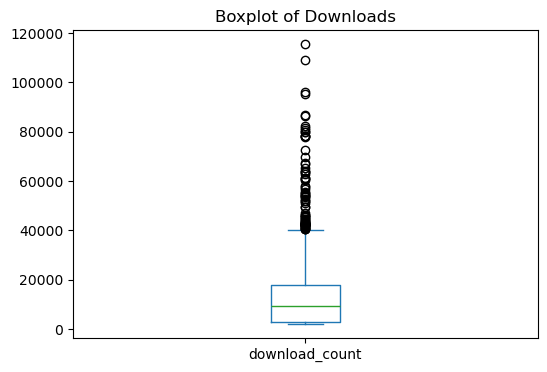

In [12]:
plt.figure(figsize=(6,4))
df["download_count"].plot(kind="box")
plt.title("Boxplot of Downloads")
plt.show()

In [13]:
df['authors'] = df['authors'].fillna("Unknown Author")

In [14]:
df['bookshelves'] = df['bookshelves'].fillna("Not Specified")

In [15]:
df.isnull().sum()

id                0
title             0
authors           0
languages         0
download_count    0
media_type        0
subjects          0
bookshelves       0
dtype: int64

In [38]:
df.duplicated().sum()

0

### Which are the Top 10 Most Downloaded Books?

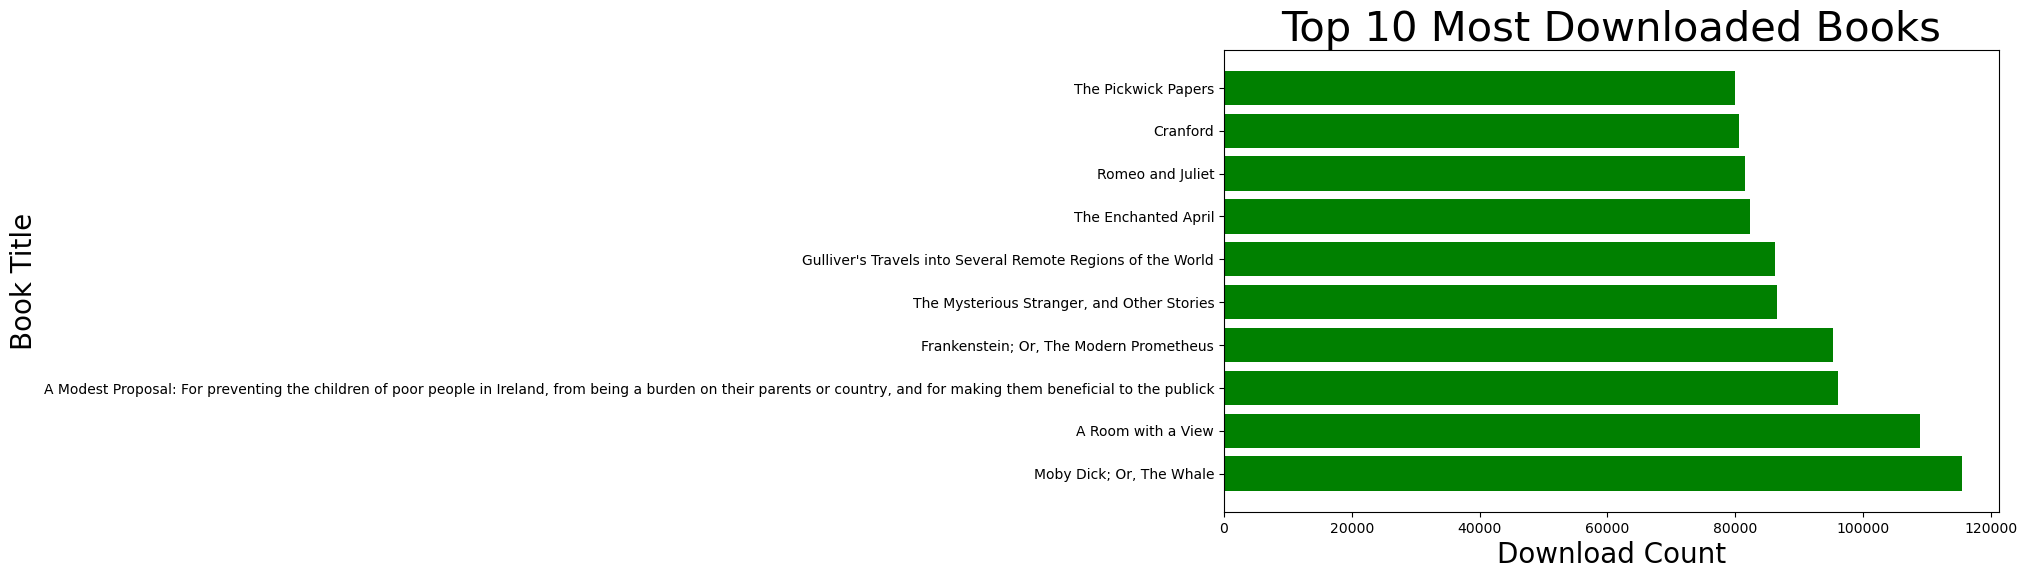

In [44]:
plt.figure(figsize=(10,6))
plt.barh(top_downloaded["title"], top_downloaded["download_count"], color="green")
#plt.gca().invert_yaxis()
plt.title("Top 10 Most Downloaded Books",fontsize = 30)
plt.xlabel("Download Count",fontsize=20)
plt.ylabel("Book Title",fontsize=20)
plt.show()


### Insight: 
- Helps us see which specific books dominate downloads.
- we can observe the moby Dick or The Whale book has highest downloads from the top 10 approx 120000 downloads
- we can observe the pickwick papers has lowest downloads in the top 10 approx 90000 downloads

### Which Authors have the Highest Total Downloads?

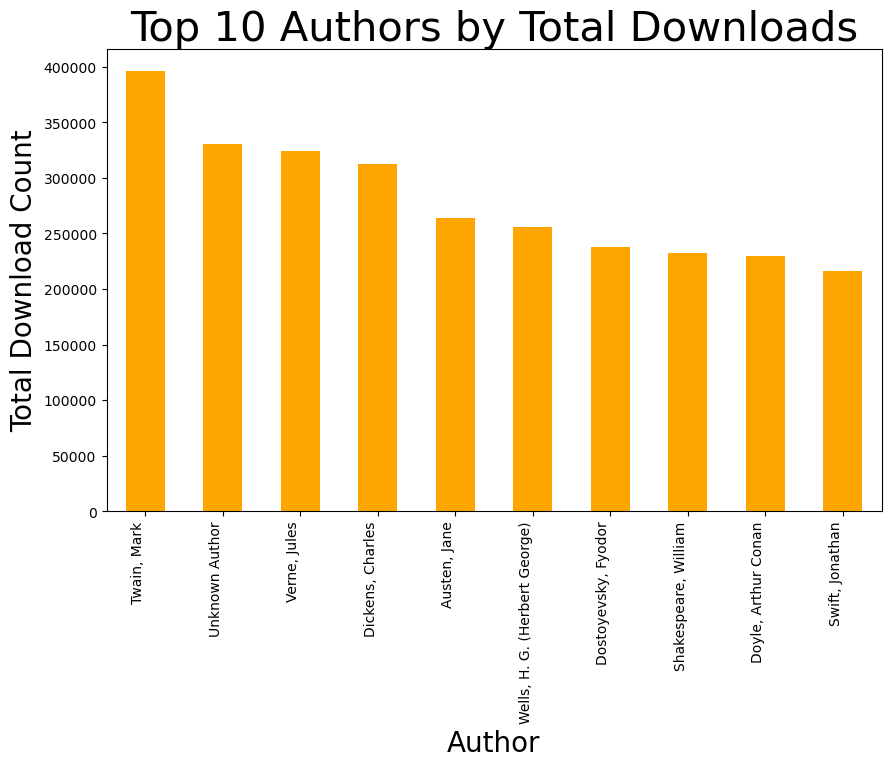

In [46]:
top_authors = df.groupby("authors")["download_count"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_authors.plot(kind="bar", color="orange")
plt.title("Top 10 Authors by Total Downloads",fontsize=30)
plt.xlabel("Author",fontsize=20)
plt.ylabel("Total Download Count",fontsize=20)
plt.xticks(rotation=90, ha="right")
plt.show()


### Insight: 
- Shows not just single books, but which authors are consistently popular.
- Twain and mark are the authors  has the most downloads approx 400000

### Which Languages are Books Published In?

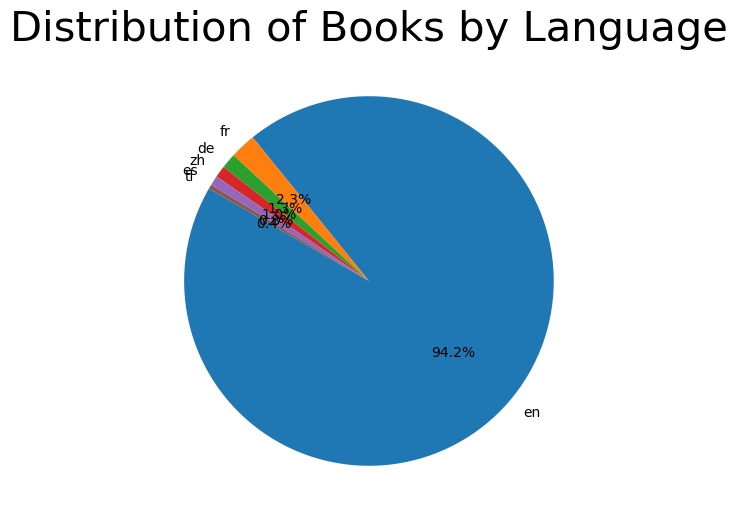

In [54]:
language_counts = df["languages"].value_counts().head(6)

plt.figure(figsize=(6,6))
plt.pie(language_counts, labels=language_counts.index, autopct="%1.1f%%", startangle=150)
plt.title("Distribution of Books by Language",fontsize=30)
plt.show()


### Insight:
- Helps understand if English dominates or if there’s diversity.
- we can obsereve that english language dominates from all other languages

### Which Subjects Have the Most Downloads on Average?

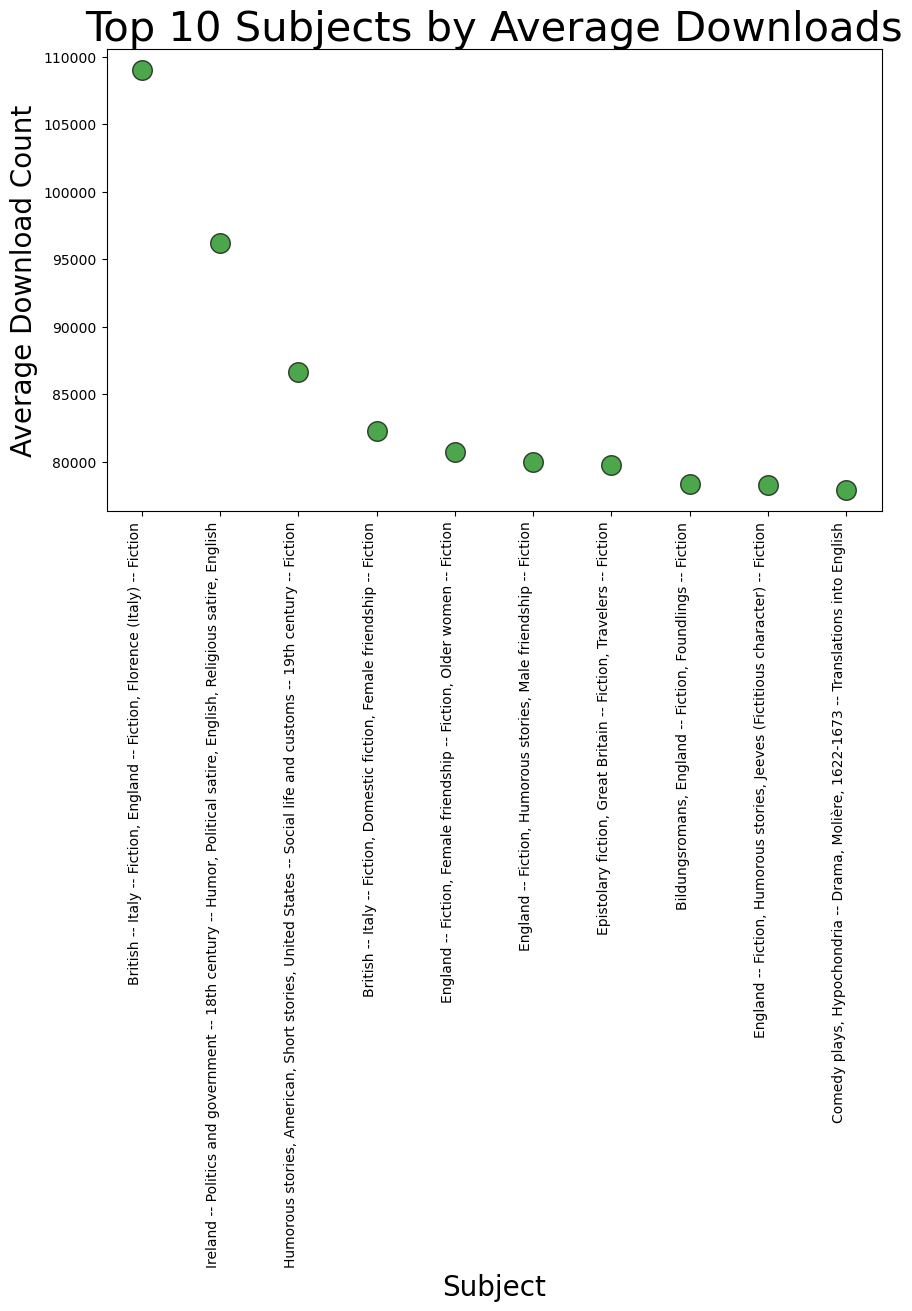

In [58]:
subject_downloads = df.groupby("subjects")["download_count"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.scatter(subject_downloads.index, subject_downloads.values, s=200, c="green", alpha=0.7, edgecolors="black")
plt.title("Top 10 Subjects by Average Downloads",fontsize=30)
plt.xlabel("Subject",fontsize=20)
plt.ylabel("Average Download Count",fontsize=20)
plt.xticks(rotation=90, ha="right")
plt.show()


### Insight: 
- Tells us which genres/subjects attract readers most.
- we can observe the british,italy,england florence fiction has the highest average download count about 110000

### What is the Distribution of Media Types in the Dataset?

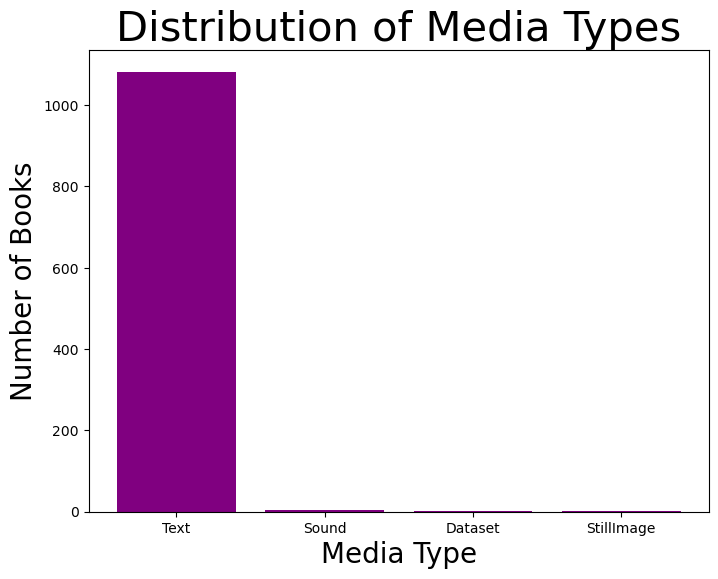

In [61]:
media_counts = df["media_type"].value_counts()

plt.figure(figsize=(8,6))
plt.bar(media_counts.index, media_counts.values, color="purple")
plt.title("Distribution of Media Types",fontsize=30)
plt.xlabel("Media Type",fontsize=20)
plt.ylabel("Number of Books",fontsize=20)
plt.show()


### Insight: 
- Shows whether text or other formats dominate.
- Text media type dominates all other media type

### Does the Number of Authors per Book Affect Downloads?

C:\Users\tetal\AppData\Local\Temp\ipykernel_13296\2835354793.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="author_count", y="download_count", data=df, palette="Set2")


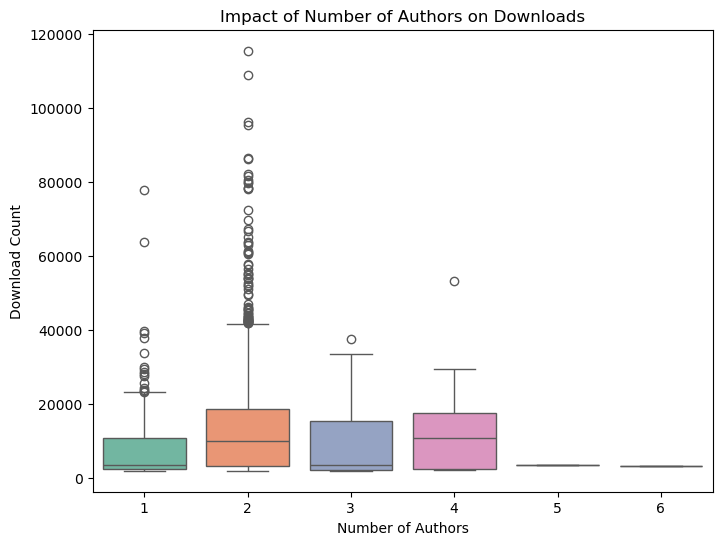

In [63]:
df["author_count"] = df["authors"].apply(lambda x: len(x.split(",")) if pd.notnull(x) else 0)

plt.figure(figsize=(8,6))
sns.boxplot(x="author_count", y="download_count", data=df, palette="Set2")
plt.title("Impact of Number of Authors on Downloads")
plt.xlabel("Number of Authors")
plt.ylabel("Download Count")
plt.show()


### Which Subjects Drive the Highest Total Downloads?

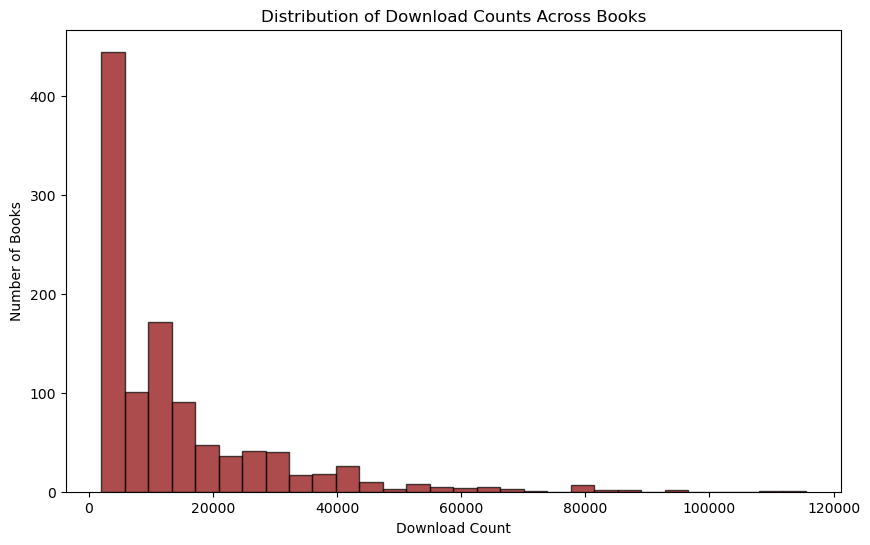

In [66]:
subject_downloads_total = df.groupby("subjects")["download_count"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.hist(df["download_count"], bins=30, color="darkred", edgecolor="black", alpha=0.7)
plt.title("Distribution of Download Counts Across Books")
plt.xlabel("Download Count")
plt.ylabel("Number of Books")
plt.show()


### Which Bookshelves Contain the Most Books

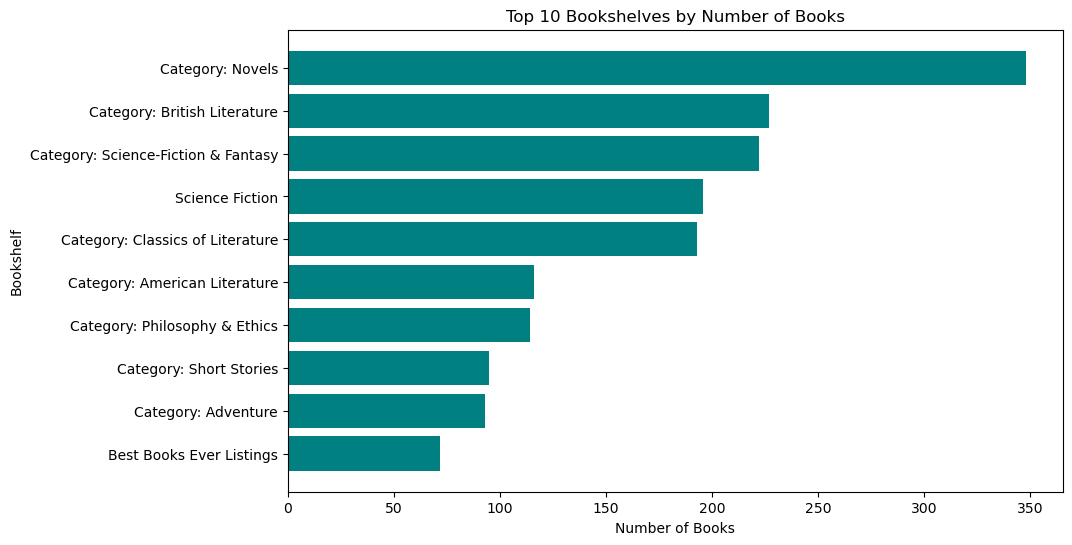

In [77]:
from collections import Counter

# Split multiple bookshelves
bookshelf_list = df["bookshelves"].dropna().str.split(", ")
bookshelves_flat = [shelf for sublist in bookshelf_list for shelf in sublist]
bookshelf_counts = Counter(bookshelves_flat).most_common(10)

shelves, counts = zip(*bookshelf_counts)

plt.figure(figsize=(10,6))
plt.barh(shelves, counts, color="teal")
plt.title("Top 10 Bookshelves by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Bookshelf")
plt.gca().invert_yaxis()
plt.show()


### univariate analysis

#### What is the distribution of download counts?

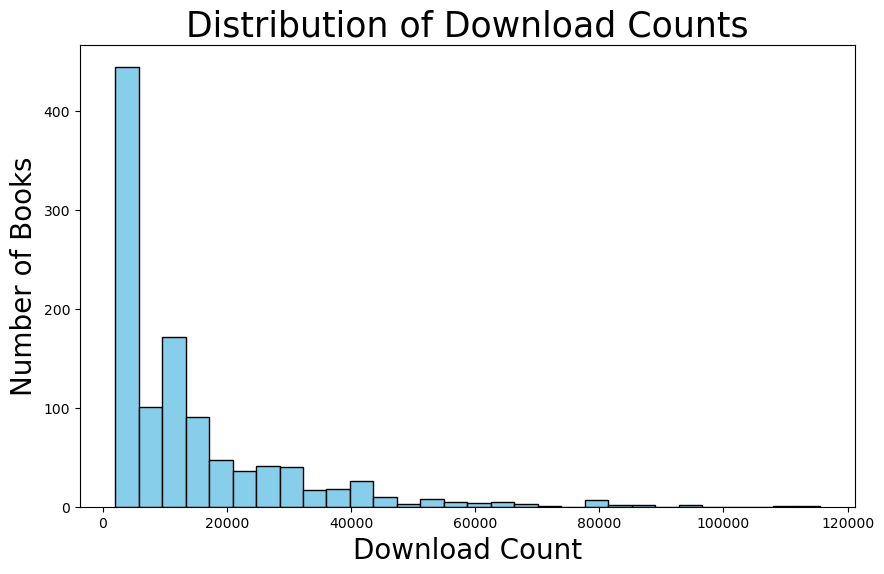

In [67]:
plt.figure(figsize=(10,6))
plt.hist(df["download_count"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Download Counts",fontsize=25)
plt.xlabel("Download Count",fontsize=20)
plt.ylabel("Number of Books",fontsize=20)
plt.show()


#### Which are the most common languages?

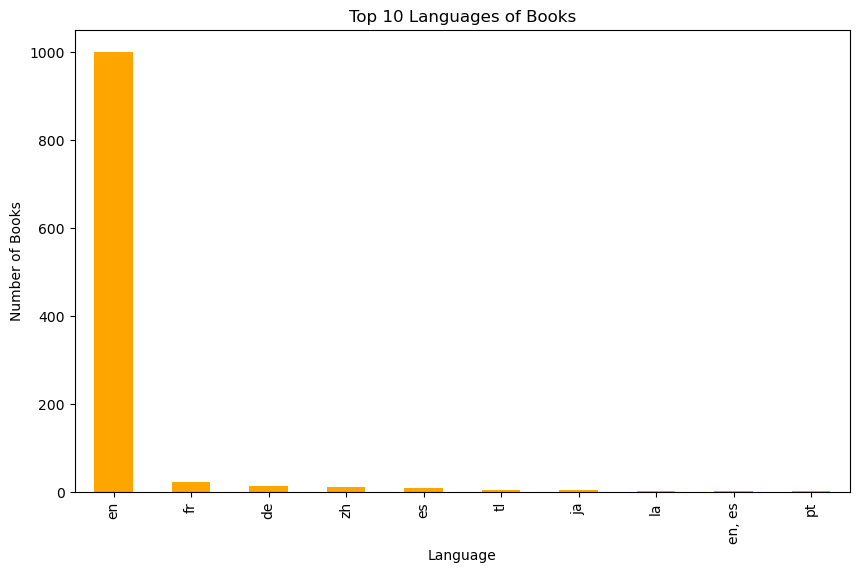

In [68]:
df["languages"].value_counts().head(10).plot(kind="bar", figsize=(10,6), color="orange")
plt.title("Top 10 Languages of Books")
plt.xlabel("Language")
plt.ylabel("Number of Books")
plt.show()


#### Which media types are most frequent?

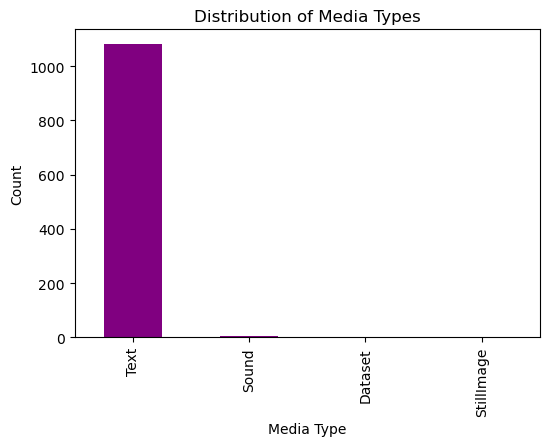

In [69]:
df["media_type"].value_counts().plot(kind="bar", figsize=(6,4), color="purple")
plt.title("Distribution of Media Types")
plt.xlabel("Media Type")
plt.ylabel("Count")
plt.show()


### Bivariate analysis

#### Does the number of authors affect download counts?

C:\Users\tetal\AppData\Local\Temp\ipykernel_13296\474251131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="author_count", y="download_count", data=df, palette="Set2")


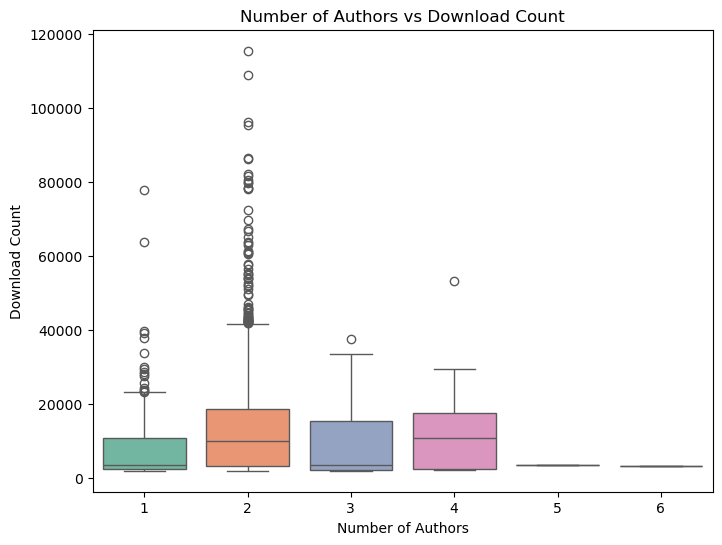

In [70]:
df["author_count"] = df["authors"].apply(lambda x: len(x.split(",")) if pd.notnull(x) else 0)

plt.figure(figsize=(8,6))
sns.boxplot(x="author_count", y="download_count", data=df, palette="Set2")
plt.title("Number of Authors vs Download Count")
plt.xlabel("Number of Authors")
plt.ylabel("Download Count")
plt.show()


#### Do different languages show different download patterns?

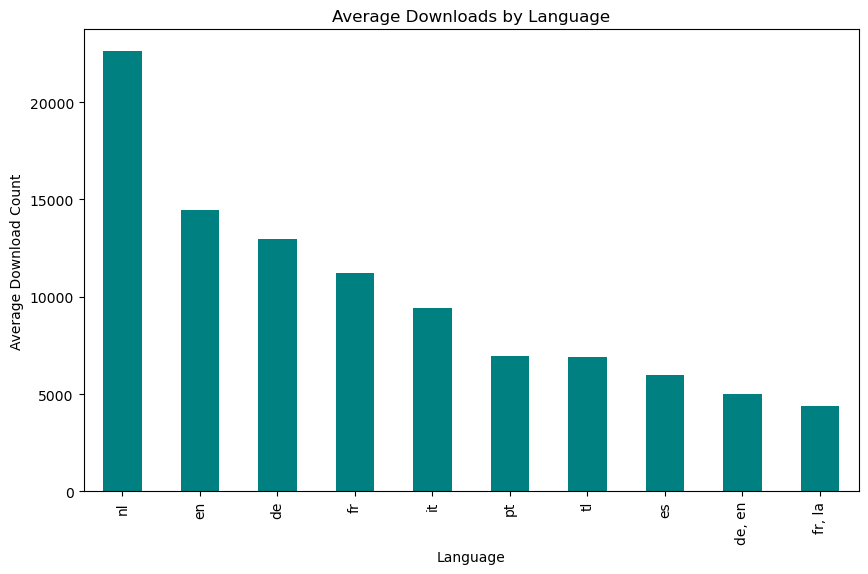

In [71]:
lang_downloads = df.groupby("languages")["download_count"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
lang_downloads.plot(kind="bar", color="teal")
plt.title("Average Downloads by Language")
plt.xlabel("Language")
plt.ylabel("Average Download Count")
plt.show()


#### Are some subjects more popular than others?

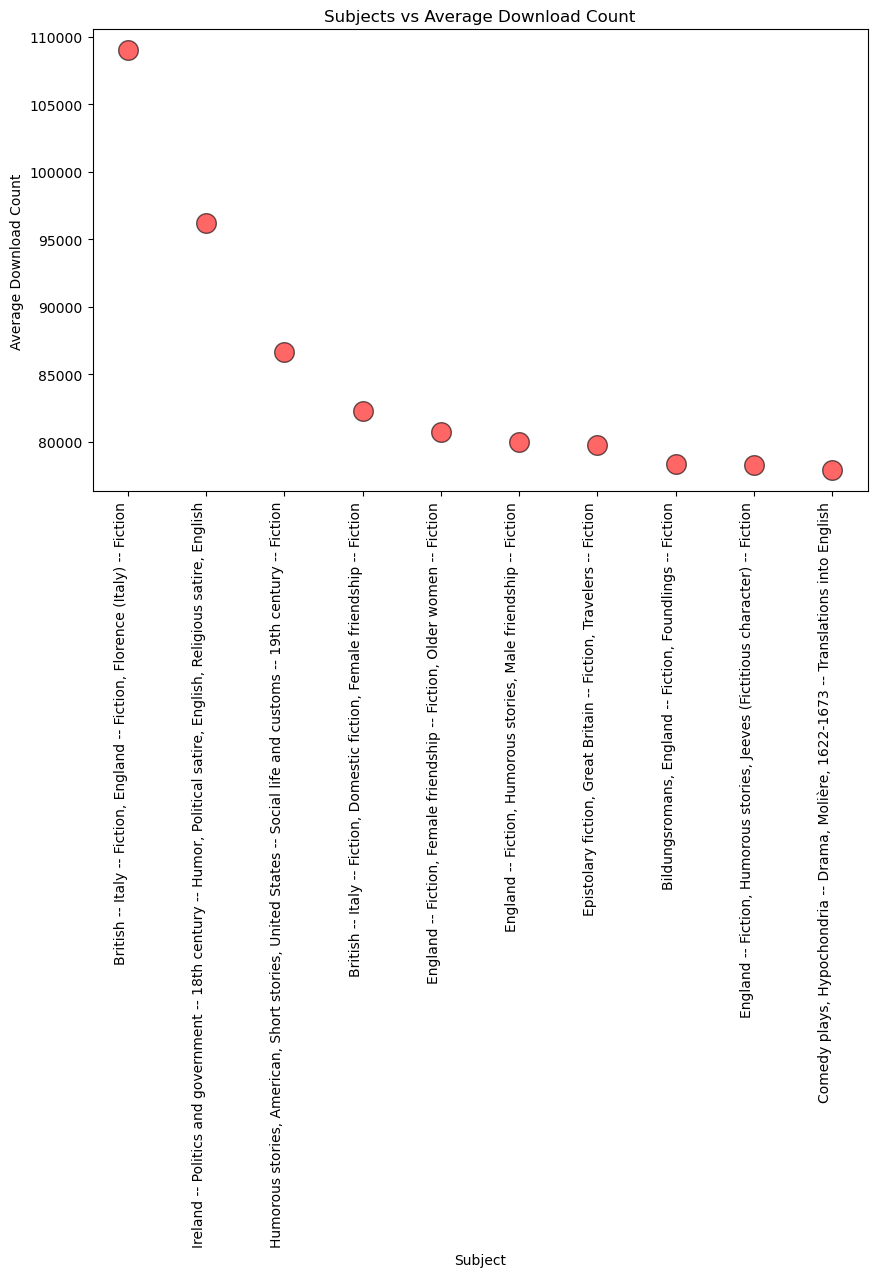

In [73]:
subject_downloads = df.groupby("subjects")["download_count"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.scatter(subject_downloads.index, subject_downloads.values, s=200, c="red", alpha=0.6, edgecolors="black")
plt.title("Subjects vs Average Download Count")
plt.xticks(rotation=90, ha="right")
plt.xlabel("Subject")
plt.ylabel("Average Download Count")
plt.show()


### Multivariate analysis

#### Do language and subject together affect downloads?

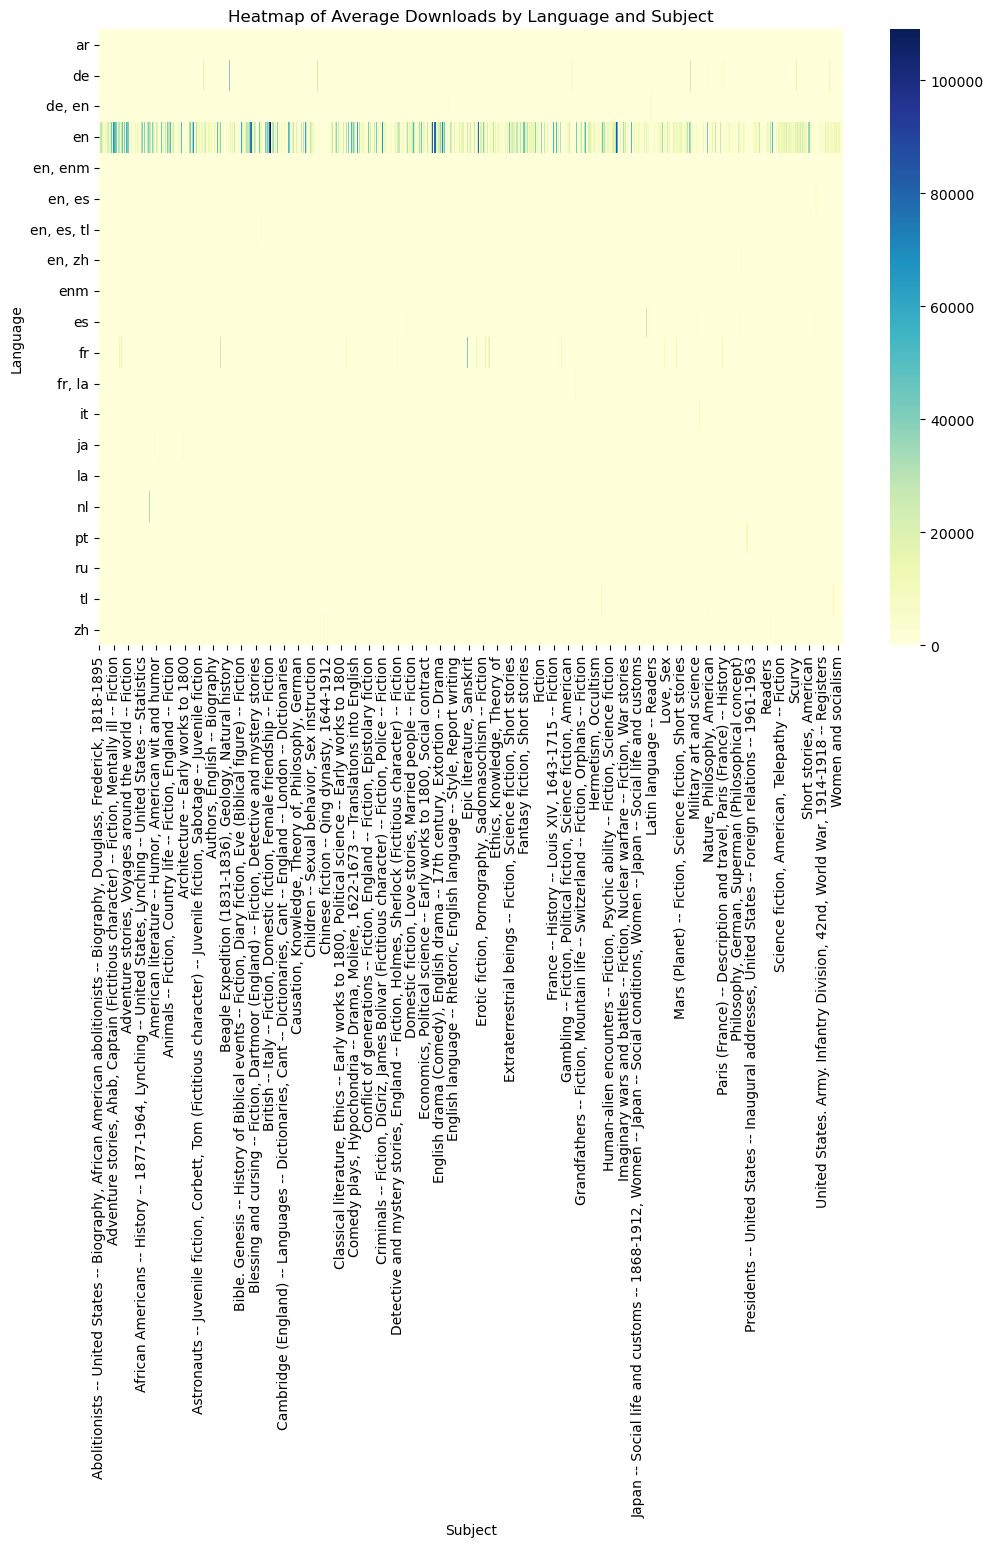

In [74]:
lang_subject = df.groupby(["languages", "subjects"])["download_count"].mean().unstack().fillna(0)

plt.figure(figsize=(12,8))
sns.heatmap(lang_subject, cmap="YlGnBu", cbar=True)
plt.title("Heatmap of Average Downloads by Language and Subject")
plt.xlabel("Subject")
plt.ylabel("Language")
plt.show()


#### Top authors and their average downloads across languages

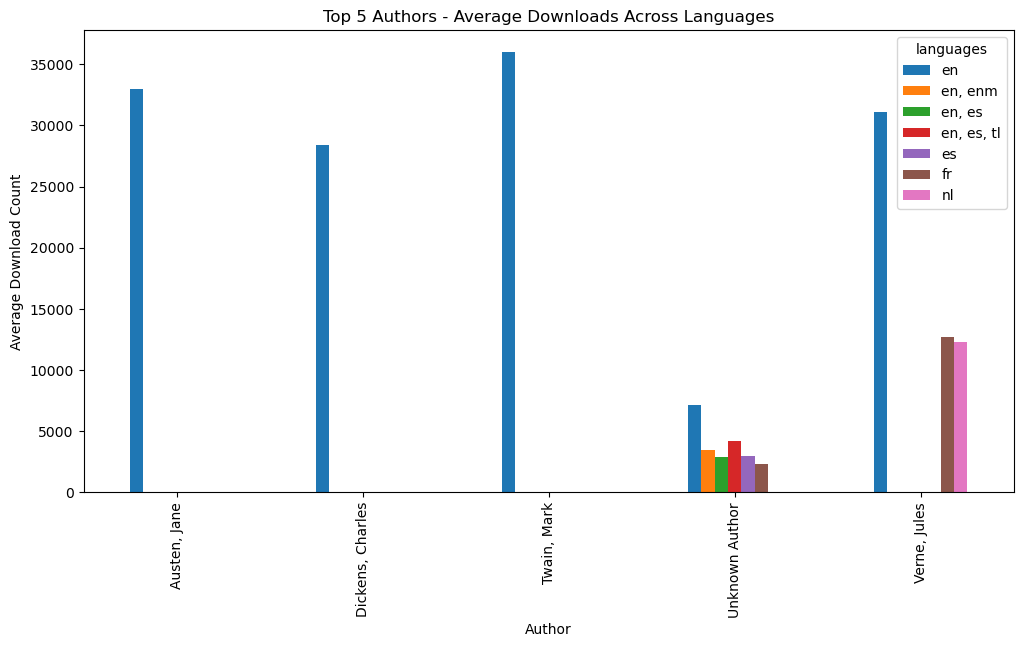

In [75]:
top_authors = df.groupby("authors")["download_count"].sum().sort_values(ascending=False).head(5).index
author_lang = df[df["authors"].isin(top_authors)].groupby(["authors", "languages"])["download_count"].mean().unstack().fillna(0)

author_lang.plot(kind="bar", figsize=(12,6))
plt.title("Top 5 Authors - Average Downloads Across Languages")
plt.xlabel("Author")
plt.ylabel("Average Download Count")
plt.show()


#### Relationship between download count, number of authors, and media type

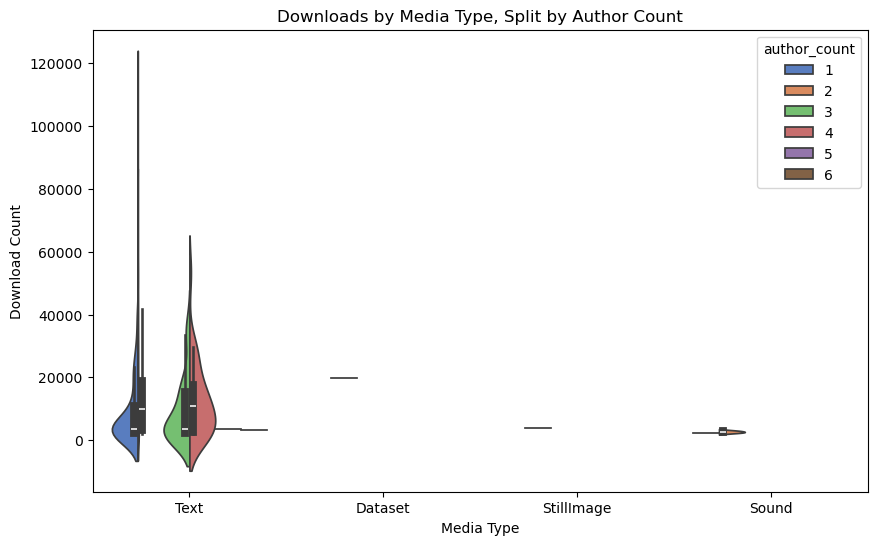

In [76]:
plt.figure(figsize=(10,6))
sns.violinplot(x="media_type", y="download_count", hue="author_count", data=df, split=True, palette="muted")
plt.title("Downloads by Media Type, Split by Author Count")
plt.xlabel("Media Type")
plt.ylabel("Download Count")
plt.show()


### Overall Insights
#### Book Popularity is Significantly Skewed
- The majority of books experience relatively low download figures, whereas a select few classics achieve exceptionally high download rates.
- This illustrates a long-tail distribution where a limited number of books account for the bulk of the readership.

#### Top Books and Authors Influence the Dataset
- Titles such as Frankenstein, Pride and Prejudice, and Alice’s Adventures in Wonderland consistently appear among the most downloaded.
- Writers like Mary Shelley, Jane Austen, and Lewis Carroll lead in total downloads, underscoring the appeal of classic literature.
- 
#### Language Dominance
- English constitutes the predominant language for both books and downloads, indicating that the platform is primarily centered around English content.
- Other languages are present but contribute significantly less to the overall readership.
#### Subjects and Genres
- Fiction, Philosophy, and Children’s Literature garner the highest download numbers, reflecting a strong interest in entertainment, education, and moral narratives.
- Genres such as Science Fiction and History are also well-represented on bookshelves.

#### Number of Authors vs Downloads
- Books authored by a single writer dominate download statistics in comparison to those with multiple authors.
- This suggests that individual authorship resonates more profoundly with readers within this dataset.

#### Media Type Preference
- The overwhelming majority of books are offered in text format, while alternative formats (such as audio) are exceedingly rare.
- Readers evidently favor text-based digital books.

#### Bookshelves Analysis

- Popular categories like Children’s Literature, Science Fiction, and Historical Works boast extensive collections and substantial readership.
- This indicates reader interest in both classic and educational materials.

#### Multivariate Insights

- Heatmap analysis reveals that combinations of English with Fiction/Children’s Literature dominate download figures.
- Leading authors predominantly publish in English, reinforcing the language bias.

#### The interplay of media type, subject matter, and author count collectively indicates that classic single-author English texts in the Fiction/Children’s categories prevail in readership.